## 이터레이터 사용하기

이터레이터(iterator)는 값을 차례대로 꺼낼 수 있는 객체(object)입니다.

In [1]:
a =[1,2,3]
dir(a)

['__add__',
 '__class__',
 '__class_getitem__',
 '__contains__',
 '__delattr__',
 '__delitem__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__iadd__',
 '__imul__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__len__',
 '__lt__',
 '__mul__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__reversed__',
 '__rmul__',
 '__setattr__',
 '__setitem__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 'append',
 'clear',
 'copy',
 'count',
 'extend',
 'index',
 'insert',
 'pop',
 'remove',
 'reverse',
 'sort']

## 반복 가능한 객체 알아보기

In [3]:
it = [1,2,3].__iter__()

In [4]:
it.__next__()

1

In [5]:
it.__next__()

2

In [6]:
it.__next__()

3

In [7]:
it.__next__()

StopIteration: 

StopIteration 예외가 발생

In [8]:
'Hello, world!'.__iter__()

In [9]:
{'a': 1, 'b': 2}.__iter__()

In [10]:
{1, 2, 3}.__iter__()

리스트, 문자열, 딕셔너리, 세트는 요소가 눈에 보이는 반복 가능한 객체

## 요소가 눈에 보이지 않는 range

In [11]:
it = range(3).__iter__()

In [12]:
it.__next__()

0

In [13]:
it.__next__()

1

In [14]:
it.__next__()

2

In [15]:
it.__next__()

StopIteration: 

it에서 __next__를 호출할 때마다 0부터 숫자가 증가해서 2까지 나왔습니다. 그리고 2 다음에 __next__를 호출했을 때 StopIteration 예외가 발생했습니다. 즉, range(3)이므로 0, 1, 2 세 번 반복하며 요소가 눈에 보이지 않지만 지정된 만큼 숫자를 꺼내서 반복할 수 있습니다.

##  for와 반복 가능한 객체

 for에서 range의 동작 과정

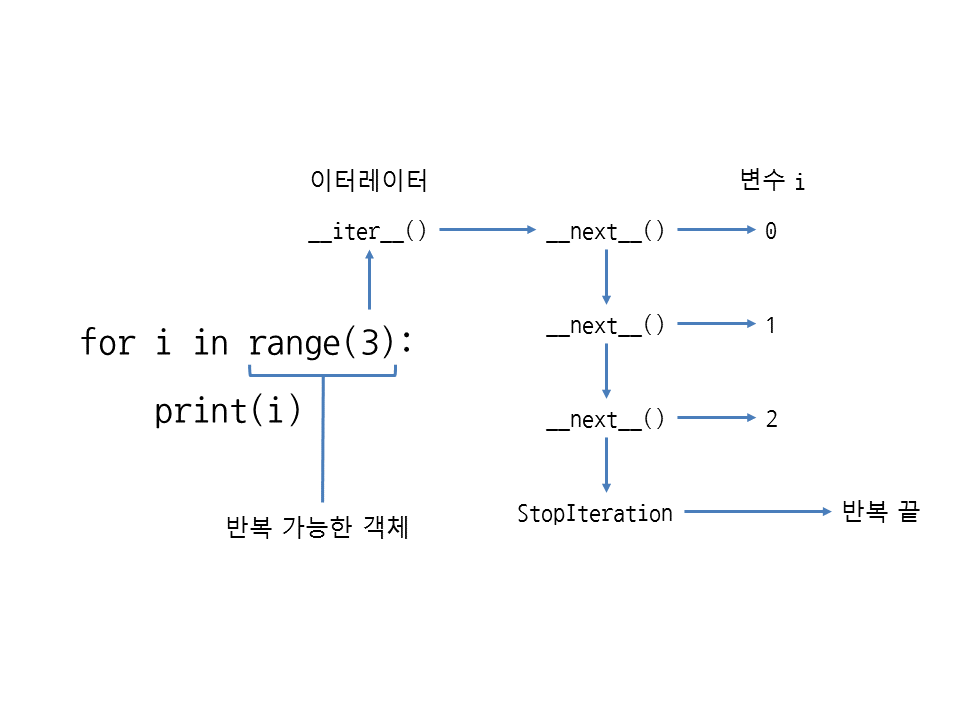

 반복 가능한 객체는 요소를 한 번에 하나씩 가져올 수 있는 객체이고, 이터레이터는 __next__ 메서드를 사용해서 차례대로 값을 꺼낼 수 있는 객체입니다. 반복 가능한 객체(iterable)와 이터레이터(iterator)는 별개의 객체이므로 둘은 구분해야 합니다. 즉, 반복 가능한 객체에서 __iter__ 메서드로 이터레이터를 얻습니다.

반복 가능한 객체는 시퀀스 객체를 포함

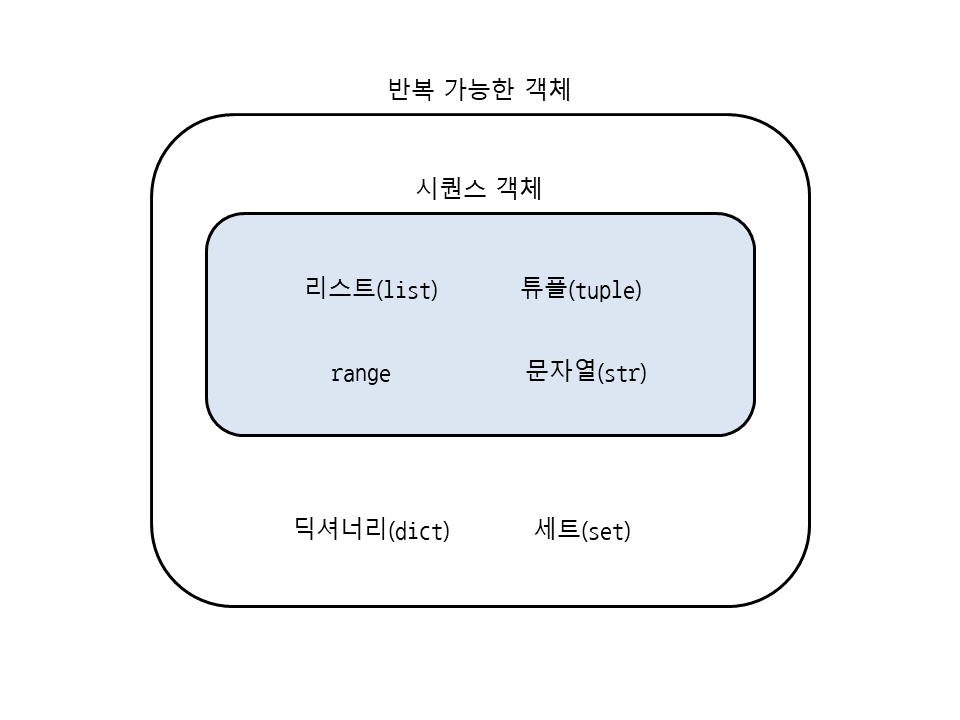

## 이터레이터 만들기

In [16]:
class Counter:
    def __init__(self, stop):
        self.current = 0    # 현재 숫자 유지, 0부터 지정된 숫자 직전까지 반복
        self.stop = stop    # 반복을 끝낼 숫자
 
    def __iter__(self):
        return self         # 현재 인스턴스를 반환
 
    def __next__(self):
        if self.current < self.stop:    # 현재 숫자가 반복을 끝낼 숫자보다 작을 때
            r = self.current            # 반환할 숫자를 변수에 저장
            self.current += 1           # 현재 숫자를 1 증가시킴
            return r                    # 숫자를 반환
        else:                           # 현재 숫자가 반복을 끝낼 숫자보다 크거나 같을 때
            raise StopIteration         # 예외 발생
 
for i in Counter(3):
    print(i, end=' ')

0 1 2 

## 이터레이터 언패킹

In [17]:
a,b,c = Counter(3)
print(a,b,c)

0 1 2


In [18]:
a, b, c, d, e = Counter(5)
print(a,b,c,d,e)

0 1 2 3 4


## 인덱스로 접근할 수 있는 이터레이터 만들기

In [19]:
class Counter:
    def __init__(self, stop):
        self.stop = stop
 
    def __getitem__(self, index):
        if index < self.stop:
            return index
        else:
            raise IndexError
 
print(Counter(3)[0], Counter(3)[1], Counter(3)[2])
 
for i in Counter(3):
    print(i, end=' ')

0 1 2
0 1 2 